<a href="https://colab.research.google.com/github/swagatadutta26/agriculture-prediction-system/blob/main/Agriculture_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, f1_score

# **Load Dataset**

In [2]:
df = pd.read_csv("/content/soil_measures.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2200, 5)


,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


# **Data Exploration**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB
None
                 N            P            K           ph
count  2200.000000  2200.000000  2200.000000  2200.000000
mean     50.551818    53.362727    48.149091     6.469480
std      36.917334    32.985883    50.647931     0.773938
min       0.000000     5.000000     5.000000     3.504752
25%      21.000000    28.000000    20.000000     5.971693
50%      37.000000    51.000000    32.000000     6.425045
75%      84.250000    68.000000    49.000000     6.923643
max     140.000000   145.000000   205.000000     9.935091


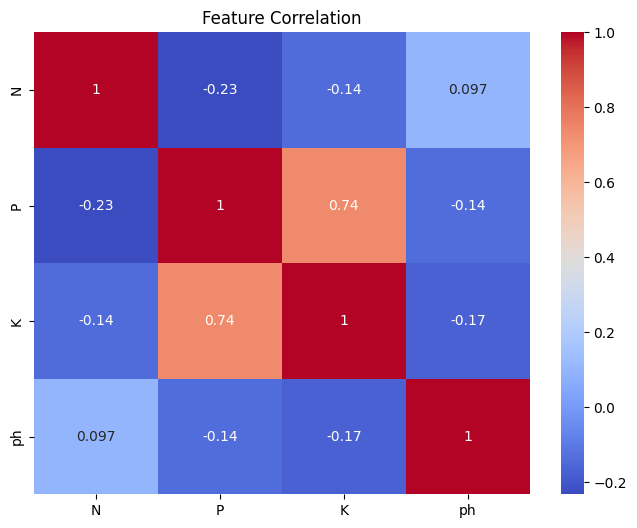

In [3]:
print(df.info())
print(df.describe())

plt.figure(figsize=(8,6))
sns.heatmap(df[['N','P','K','ph']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# **Feature Selection**

In [4]:
X = df[['N','P','K','ph']]
y = df['crop']

# **Train-Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Compare Models**

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([name, accuracy])

    print(f"\n{name}")
    print("Accuracy:", round(accuracy,4))


Logistic Regression
Accuracy: 0.6682

Decision Tree
Accuracy: 0.3818

Naive Bayes
Accuracy: 0.775

Random Forest
Accuracy: 0.8114

SVM
Accuracy: 0.6045


# **Select Best Model**

In [7]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

RandomForestClassifier()

# **Prediction Function**

In [8]:
def predict_crop(N, P, K, ph):

    sample = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "ph": [ph]
    })

    prediction = best_model.predict(sample)

    return prediction[0]

# **Example Prediction**

In [9]:
crop = predict_crop(
    N=50,
    P=40,
    K=60,
    ph=6.5
)

print("Recommended Crop:", crop)

Recommended Crop: papaya
